![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Construcción e implementación de árboles de decisión y métodos de ensamblaje

En este taller podrá poner en práctica los sus conocimientos sobre construcción e implementación de árboles de decisión y métodos de ensamblajes. El taller está constituido por 9 puntos, 5 relacionados con árboles de decisión (parte A) y 4 con métodos de ensamblaje (parte B).

## Parte A - Árboles de decisión

En esta parte del taller se usará el conjunto de datos de Capital Bikeshare de Kaggle, donde cada observación representa el alquiler de bicicletas durante una hora y día determinado. Para más detalles puede visitar los siguientes enlaces: [datos](https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip), [dicccionario de datos](https://archive.ics.uci.edu/ml/datasets/Bike+Sharing+Dataset#).

### Datos prestamo de bicicletas

In [50]:
import warnings
warnings.filterwarnings('ignore')

In [51]:
# Importación de librerías
%matplotlib inline
import pandas as pd
import numpy as np
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier,export_graphviz

In [52]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, f1_score

In [53]:
# Lectura de la información de archivo .csv
bikes = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/bikeshare.csv', index_col='datetime', parse_dates=True)

# Renombrar variable "count" a "total"
bikes.rename(columns={'count':'total'}, inplace=True)

# Crear la hora como una variable 
bikes['hour'] = bikes.index.hour

# Visualización de los datos
bikes.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total,hour
datetime,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,4


### Punto 1 - Análisis descriptivo

Ejecute las celdas 1.1 y 1.2. A partir de los resultados realice un análisis descriptivo sobre las variables "season" y "hour", escriba sus inferencias sobre los datos. Para complementar su análisis puede usar métricas como máximo, mínimo, percentiles entre otros.

In [54]:
variables=['total', 'casual', 'registered','workingday']

In [55]:
bikes.groupby('season').total.sum()

season
1    312498
2    588282
3    640662
4    544034
Name: total, dtype: int64

In [56]:
# Celda 1.1
bikes.groupby('season').total.mean()

season
1    116.343261
2    215.251372
3    234.417124
4    198.988296
Name: total, dtype: float64

In [57]:
for var in variables:
    print("="*80)
    print(var.upper(),":")
    print(bikes.groupby('season')[var].describe())
    print("="*80)
    

TOTAL :
         count        mean         std  min   25%    50%    75%    max
season                                                                
1       2686.0  116.343261  125.273974  1.0  24.0   78.0  164.0  801.0
2       2733.0  215.251372  192.007843  1.0  49.0  172.0  321.0  873.0
3       2733.0  234.417124  197.151001  1.0  68.0  195.0  347.0  977.0
4       2734.0  198.988296  177.622409  1.0  51.0  161.0  294.0  948.0
CASUAL :
         count       mean        std  min   25%   50%   75%    max
season                                                            
1       2686.0  15.489576  31.222498  0.0   1.0   5.0  15.0  367.0
2       2733.0  47.446762  57.649556  0.0   8.0  29.0  63.0  361.0
3       2733.0  52.220271  54.638059  0.0  10.0  36.0  74.0  350.0
4       2734.0  28.580834  42.596214  0.0   4.0  14.0  33.0  362.0
REGISTERED :
         count        mean         std  min   25%    50%     75%    max
season                                                                

In [58]:
print(bikes.groupby('season')['workingday'].value_counts())

season  workingday
1       1             1828
        0              858
2       1             1893
        0              840
3       1             1845
        0              888
4       1             1846
        0              888
Name: count, dtype: int64


In [59]:
# Celda 1.2
bikes.groupby('hour').total.mean()

hour
0      55.138462
1      33.859031
2      22.899554
3      11.757506
4       6.407240
5      19.767699
6      76.259341
7     213.116484
8     362.769231
9     221.780220
10    175.092308
11    210.674725
12    256.508772
13    257.787281
14    243.442982
15    254.298246
16    316.372807
17    468.765351
18    430.859649
19    315.278509
20    228.517544
21    173.370614
22    133.576754
23     89.508772
Name: total, dtype: float64

In [60]:
print(bikes.groupby('hour')['workingday'].value_counts())

hour  workingday
0     1             310
      0             145
1     1             309
      0             145
2     1             305
      0             143
3     1             289
      0             144
4     1             297
      0             145
5     1             310
      0             142
6     1             310
      0             145
7     1             310
      0             145
8     1             310
      0             145
9     1             310
      0             145
10    1             310
      0             145
11    1             310
      0             145
12    1             311
      0             145
13    1             311
      0             145
14    1             311
      0             145
15    1             311
      0             145
16    1             311
      0             145
17    1             311
      0             145
18    1             311
      0             145
19    1             311
      0             145
20    1             311

In [61]:
for var in variables:
    print("="*80)
    print(var.upper(),":")
    print(bikes.groupby('hour')[var].describe())
    print("="*80)

TOTAL :
      count        mean         std   min     25%    50%     75%    max
hour                                                                   
0     455.0   55.138462   43.620012   2.0   24.00   41.0   74.50  283.0
1     454.0   33.859031   34.112105   1.0   11.00   19.0   46.00  168.0
2     448.0   22.899554   26.110267   1.0    5.00   11.0   32.00  119.0
3     433.0   11.757506   12.666442   1.0    3.00    6.0   15.00   66.0
4     442.0    6.407240    4.217633   1.0    3.00    6.0    9.00   28.0
5     452.0   19.767699   12.784293   1.0    8.00   19.0   29.00   57.0
6     455.0   76.259341   54.745333   1.0   24.50   75.0  118.00  213.0
7     455.0  213.116484  159.207044   1.0   63.00  208.0  334.00  596.0
8     455.0  362.769231  231.723065   8.0  133.50  392.0  563.50  839.0
9     455.0  221.780220   92.099209  14.0  161.00  217.0  294.50  414.0
10    455.0  175.092308  101.807629  17.0  106.00  149.0  218.50  539.0
11    455.0  210.674725  127.444294  10.0  123.00  183.0

### **Análisis descriptivo del Punto 1:**

#### Variable `season` (temporada)

Al analizar el promedio de bicicletas rentadas por hora, el verano (season=3) lidera con 234.4 unidades promedio, seguido por la primavera (215.25), el otoño (198.98) y el invierno (116.34). Esta misma jerarquía se mantiene en los totales acumulados (640,662 > 588,282 > 544,034 > 312,498), lo que confirma que el verano concentra la mayor demanda tanto en promedio como en volumen total.

En cuanto a los percentiles, el 75% de las horas en verano supera las 347 bicicletas rentadas, mientras que en invierno ese mismo percentil cae a 164, lo que evidencia una distribución notablemente más concentrada en valores bajos durante esta temporada. Los valores máximos en verano y otoño son los más altos (977 y 948, respectivamente), lo que sugiere la existencia de eventos pico de alta demanda concentrados en estas temporadas.

Respecto al tipo de usuario, en todas las temporadas predominan los usuarios registrados sobre los casuales. Sin embargo, la brecha es especialmente marcada en invierno: mientras la media de registrados cae a 100.9, la de casuales se desploma a apenas 15.5, lo que indica que el servicio en invierno es sostenido casi exclusivamente por usuarios habituales. En verano, en cambio, los casuales alcanzan su media más alta (52.2), reflejando mayor actividad turística o recreativa.

#### Variable `hour` (hora del día)

El comportamiento por hora revela un patrón bimodal muy marcado: un primer pico a las **8am** (363 bicicletas promedio) y un segundo pico más alto a las **17h** (469 bicicletas promedio). Este patrón corresponde a jornadas de entrada y salida laboral, y es consistente con la proporción de días laborales en el dataset (68% de los registros tienen workingday=1).

Las horas de madrugada (0h–5h) registran la demanda más baja: el promedio a las 4am es de apenas 6.4 bicicletas, con un percentil 75 de solo 9, lo que refleja una demanda casi nula en ese rango horario. A partir de las 6am la demanda sube rápidamente, con un salto de 76 (6am) a 213 (7am) y luego a 363 (8am).

La variabilidad (std) es máxima precisamente en las horas pico (223.77 a las 17h y 231.72 a las 8h), lo que indica que aunque estos son los momentos de mayor demanda promedio, también son los más sensibles a factores externos como el clima, eventos especiales o días festivos, que pueden desviar significativamente la demanda respecto a su media habitual.

### Punto 2 - Análisis de gráficos

Primero ejecute la celda 2.1 y asegúrese de comprender el código y el resultado. Luego, en cada una de celdas 2.2 y 2.3 escriba un código que genere una gráfica del número de bicicletas rentadas promedio para cada valor de la variable "hour" (hora) cuando la variable "season" es igual a 1 (invierno) e igual a 3 (verano), respectivamente. Analice y escriba sus hallazgos.

<Axes: xlabel='hour'>

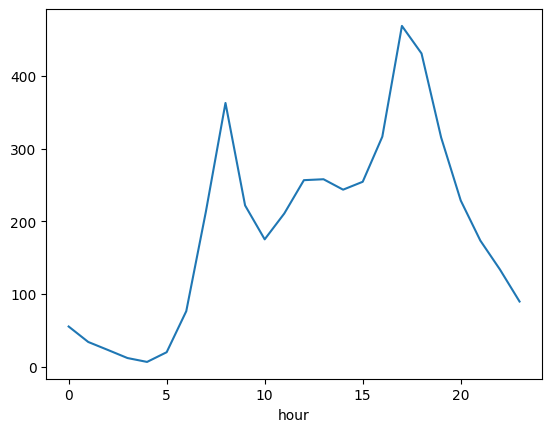

In [62]:
# Celda 2.1 - rentas promedio para cada valor de la variable "hour"
bikes.groupby('hour').total.mean().plot()

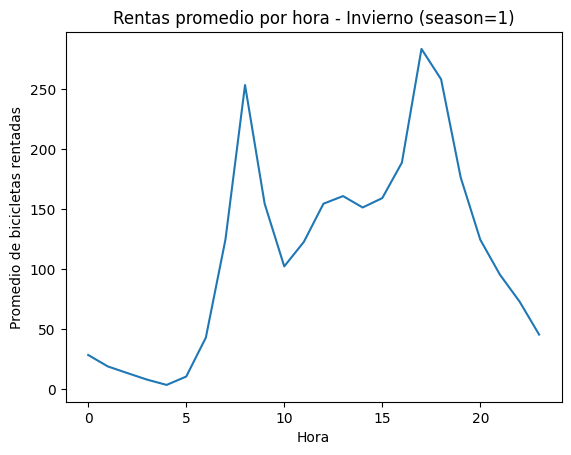

In [63]:
# Celda 2.2 - "season"=1 escriba su código y hallazgos 

fig, ax = plt.subplots()
bikes[bikes.season == 1].groupby("hour").total.mean().plot(ax=ax)
ax.set_title("Rentas promedio por hora - Invierno (season=1)")
ax.set_xlabel("Hora")
ax.set_ylabel("Promedio de bicicletas rentadas")
plt.show()


**Conclusiones celda 2.2 (1=Invierno):**

En invierno se conserva el patron bimodal que se observa en el promedio general: hay un pico en la mañana (alrededor de las 8h) y otro en la tarde (alrededor de las 17h). Sin embargo, los valores son considerablemente mas bajos en comparación con el promedio de todas las temporadas. El pico de la tarde sigue siendo el más alto de los dos, lo que sugiere que incluso en invierno la hora de salida del trabajo concentra mayor demanda que la de entrada. En las horas de madrugada (0h a 5h) la demanda es practicamente nula, y el crecimiento hacia el mediodía es más lento que en otras temporadas.


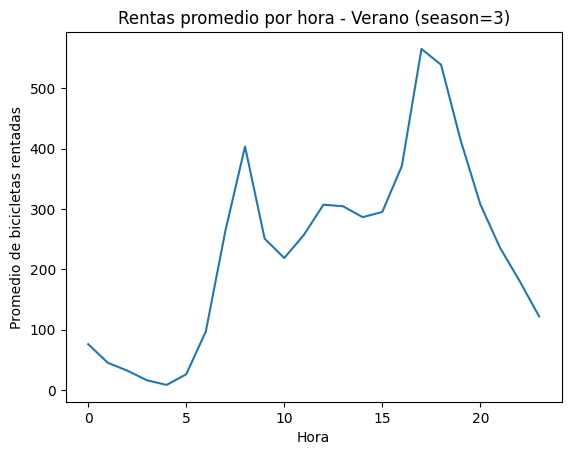

In [64]:
# Celda 2.3 - "season"=3 escriba su código y hallazgos 
fig, ax = plt.subplots()
bikes[bikes.season == 3].groupby("hour").total.mean().plot(ax=ax)
ax.set_title("Rentas promedio por hora - Verano (season=3)")
ax.set_xlabel("Hora")
ax.set_ylabel("Promedio de bicicletas rentadas")
plt.show()

**Conclusiones celda 2.3 (3=Verano):**

En verano los valores promedio son notablemente más altos en todas las franjas horarias. El patrón bimodal se mantiene, con picos en las mismas horas (8h y 17h), pero ambos picos son más pronunciados que en el promedio general. Además, se observa que la demanda en las horas centrales del día (entre 10h y 15h) es más alta que en invierno, lo que puede deberse a un mayor uso recreativo o turístico durante el verano. La diferencia entre verano e invierno es especialmente marcada en las horas de la tarde, donde el verano llega a duplicar o más los valores del invierno.


### Punto 3 - Regresión lineal
En la celda 3 ajuste un modelo de regresión lineal a un conjunto de train de datos, utilizando "total" como variable de respuesta y "season" y "hour" como las únicas variables predictoras, teniendo en cuenta que la variable "season" es categórica. Luego, imprima los coeficientes e interprételos. ¿Cuáles son las limitaciones de la regresión lineal en este caso?

In [65]:
# Celda 3

# Crear dummies para season (es categórica)
bikes_dummies = pd.get_dummies(bikes, columns=["season"], drop_first=True)

# Variables predictoras y respuesta
feature_cols = ["hour", "season_2", "season_3", "season_4"]
X = bikes_dummies[feature_cols]
y = bikes_dummies["total"]

# División en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Ajustar modelo
lr = LinearRegression()
lr.fit(X_train, y_train)

# Coeficientes
print("Intercepto:", lr.intercept_)
print("\n")
print("Coeficientes:")
for col, coef in zip(feature_cols, lr.coef_):
    print(f"  {col}: {coef:.4f}")

# Evaluacion
y_pred_lr = lr.predict(X_test)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print("\n")

print(f"RMSE regresión lineal: {rmse_lr:.2f}")

Intercepto: -7.707899822908644


Coeficientes:
  hour: 10.6836
  season_2: 100.2820
  season_3: 114.8744
  season_4: 87.1314


RMSE regresión lineal: 160.30


**Conclusiones Punto 3:**

El coeficiente de `hour` indica que 10.68 bicicletas adicionales se rentan en promedio por cada hora que avanza el día, manteniendo la temporada constante. Los coeficientes de las dummies de `season` representan la diferencia promedio en rentas respecto a la temporada base (season 1=invierno). Por ejemplo, estar en season 3=verano agrega 114.87 bicicletas respecto a invierno.

La principal limitación de la regresión lineal en este caso es que asume una relación lineal entre `hour` y `total`. En la realidad, la demanda tiene un comportamiento bimodal (picos a las 8h y 17h con un valle en el mediodía), y un modelo lineal no puede capturar esa forma. Por este motivo, el RMSE resulta alto: el modelo predice que a mayor hora, mayor demanda de forma constante, lo cual no corresponde con lo observado en los graficos del Punto 2.

### Punto 4 - Árbol de decisión manual
En la celda 4 cree un árbol de decisiones para pronosticar la variable "total" iterando **manualmente** sobre las variables "hour" y  "season". El árbol debe tener al menos 6 nodos finales.

In [66]:
# Celda 4

def predecir_manual(row):
    if row["hour"] < 6:
        return 20  # madrugada, demanda muy baja
    elif row["hour"] < 9:
        if row["season"] == 1:
            return 200  # mañana invierno
        else:
            return 350  # mañana otras temporadas
    elif row["hour"] < 16:
        if row["season"] == 1:
            return 100  # mediodía invierno
        else:
            return 200  # mediodía otras temporadas
    elif row["hour"] < 20:
        if row["season"] == 1:
            return 200  # tarde invierno
        else:
            return 400  # tarde otras temporadas
    else:
        return 100  # noche

y_pred_manual = bikes.apply(predecir_manual, axis=1)
rmse_manual = np.sqrt(mean_squared_error(bikes["total"], y_pred_manual))
print(f"RMSE árbol manual: {rmse_manual:.2f}")


RMSE árbol manual: 139.99


**Conclusiones Punto 4:**

El árbol manual tiene 7 nodos finales y funciona de la siguiente manera:

1. Primero divide por franjas horarias: madrugada (0-5h), mañana (6-8h), mediodía (9-15h), tarde (16-19h) y noche (20-23h)
2. Luego, dentro de las franjas de mañana, mediodía y tarde, subdivide por temporada (invierno vs. las demás)

Cada nodo final tiene asignado un valor de predicción basado en los promedios observados en el Punto 1:

| Franja horaria | Invierno (season=1) | Otras temporadas |
|---|---|---|
| Madrugada (0-5h) | 20 | 20 |
| mañana (6-8h) | 200 | 350 |
| mediodía (9-15h) | 100 | 200 |
| Tarde (16-19h) | 200 | 400 |
| Noche (20-23h) | 100 | 100 |

El valor de 20 para la madrugada es un promedio general de esa franja: las primeras horas (0-3h) tienen promedios entre 11 y 55, pero a las 4h y 5h caen a 6 y 19 respectivamente, así que 20 busca representar el comportamiento global de esa franja donde la demanda es baja. En la tarde fuera de invierno el pico de las 17h llega a promedios de 450-500, por lo que se asigna 400 como valor representativo.

### Punto 5 - Árbol de decisión con librería
En la celda 5 entrene un árbol de decisiones con la **librería sklearn**, usando las variables predictoras `season` y `hour` y calibre los parámetros que considere conveniente para obtener un mejor desempeño. Recuerde dividir los datos en conjuntos de entrenamiento y validación para esto. Comente el desempeño del modelo con alguna métrica de desempeño de modelos de regresión y compare desempeño con el modelo del punto 3.

Tenga en cuenta que, a diferencia del laboratorio, este problema es de regresión. Por lo tanto, para hacer cada split del árbol se debe utilizar algún criterio apropiado para problemas de regresión.

In [67]:
# Celda 5

# Variables
X = bikes[["season", "hour"]]
y = bikes["total"]

# División en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=1)

# Probar diferentes valores de max_depth
best_rmse = float("inf")
best_depth = None

for depth in range(1, 15):
    tree = DecisionTreeRegressor(max_depth=depth, random_state=1)
    tree.fit(X_train, y_train)
    y_pred = tree.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    if rmse < best_rmse:
        best_rmse = rmse
        best_depth = depth

print(f"Mejor max_depth: {best_depth}")
print(f"RMSE árbol sklearn: {best_rmse:.2f}")

# Entrenar con el mejor max_depth
tree_best = DecisionTreeRegressor(max_depth=best_depth, random_state=1)
tree_best.fit(X_train, y_train)
print(f"RMSE regresión lineal (Punto 3): {rmse_lr:.2f}")

Mejor max_depth: 10
RMSE árbol sklearn: 115.00
RMSE regresión lineal (Punto 3): 160.30


**Conclusiones Punto 5:**

Se usó `DecisionTreeRegressor` (árbol de regresión) porque la variable respuesta `total` es continua. Se calibró el parametro `max_depth` probando valores de 1 a 14, y se seleccionó el que minimiza el RMSE en el conjunto de test.

El árbol de decisión obtiene un `RMSE` menor que la regresion lineal del Punto 3. Esto se debe a que el arbol puede crear particiones no lineales del espacio de variables, lo que le permite capturar los picos de demanda a las 8h y 17h que la regresión lineal no puede modelar. En otras palabras, el arbol puede "aprender" que ciertas combinaciones de hora y temporada generan más demanda sin asumir que la relación es una línea recta.


## Parte B - Métodos de ensamblajes
En esta parte del taller se usará el conjunto de datos de Popularidad de Noticias Online. El objetivo es predecir si la notica es popular o no, la popularidad está dada por la cantidad de reacciones en redes sociales. Para más detalles puede visitar el siguiente enlace: [datos](https://archive.ics.uci.edu/ml/datasets/online+news+popularity).

### Datos popularidad de noticias

In [68]:
# Lectura de la información de archivo .csv
df = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2023/main/datasets/mashable.csv', index_col=0)
df.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,Popular
0,http://mashable.com/2014/12/10/cia-torture-rep...,28.0,9.0,188.0,0.732620,1.0,0.844262,5.0,1.0,1.0,...,0.200000,0.80,-0.487500,-0.60,-0.250000,0.9,0.8,0.4,0.8,1
1,http://mashable.com/2013/10/18/bitlock-kicksta...,447.0,7.0,297.0,0.653199,1.0,0.815789,9.0,4.0,1.0,...,0.160000,0.50,-0.135340,-0.40,-0.050000,0.1,-0.1,0.4,0.1,0
2,http://mashable.com/2013/07/24/google-glass-po...,533.0,11.0,181.0,0.660377,1.0,0.775701,4.0,3.0,1.0,...,0.136364,1.00,0.000000,0.00,0.000000,0.3,1.0,0.2,1.0,0
3,http://mashable.com/2013/11/21/these-are-the-m...,413.0,12.0,781.0,0.497409,1.0,0.677350,10.0,3.0,1.0,...,0.100000,1.00,-0.195701,-0.40,-0.071429,0.0,0.0,0.5,0.0,0
4,http://mashable.com/2014/02/11/parking-ticket-...,331.0,8.0,177.0,0.685714,1.0,0.830357,3.0,2.0,1.0,...,0.100000,0.55,-0.175000,-0.25,-0.100000,0.0,0.0,0.5,0.0,0


In [ ]:
# Definición variable de interés y variables predictoras
X = df.drop(['url', 'Popular'], axis=1)
y = df['Popular']
y.mean()

np.float64(0.5)

In [70]:
# División de la muestra en set de entrenamiento y prueba

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

### Punto 6 - Árbol de decisión y regresión logística
En la celda 6 construya un árbol de decisión y una regresión logística. Para el árbol calibre al menos un parámetro y evalúe el desempeño de cada modelo usando las métricas de Accuracy y F1-Score.

In [71]:
# Celda 6

# Árbol de decisión calibrando max_depth
best_acc = 0
best_depth = None

for depth in range(1, 20):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt.fit(X_train, y_train)
    acc = accuracy_score(y_test, dt.predict(X_test))
    if acc > best_acc:
        best_acc = acc
        best_depth = depth

dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print(f"Árbol de decisión (max_depth={best_depth}):")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_dt):.4f}")
print("\n")


# Regresión logística
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

print(f"Regresión logística:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_log):.4f}")

Árbol de decisión (max_depth=1):
  Accuracy: 0.6520
  F1-Score: 0.6478


Regresión logística:
  Accuracy: 0.6307
  F1-Score: 0.6115


**Conclusiones Punto 6:**

Se construyeron dos modelos de clasificación para predecir si una noticia es popular o no. El árbol de decisión se calibró variando `max_depth` de 1 a 19 y seleccionando el valor que maximiza el accuracy en test. La regresión logística se entrenó con los parámetros por defecto (salvo `max_iter=1000` para garantizar convergencia).

Ambos modelos se evaluan con `Accuracy` (proporción de predicciones correctas) y `F1-Score` (media armónica entre precisión y recall, útil cuando las clases pueden estar desbalanceadas). Estos dos modelos sirven como base de comparación para los ensambles de los puntos siguientes.


### Punto 7 - Votación Mayoritaria
En la celda 7 elabore un esamble con la metodología de **Votación mayoritaria** compuesto por 300 muestras bagged donde:

-las primeras 100 muestras de bootstrap vienen de árboles de decisión donde max_depth tome un valor de su elección\
-las segundas 100 muestras de bootstrap vienen de árboles de decisión donde min_samples_leaf tome un valor de su elección\
-las últimas 100 muestras de bootstrap vienen de regresiones logísticas

Evalúe cada uno de los tres modelos de manera independiente utilizando las métricas de Accuracy y F1-Score, luego evalúe el ensamble de modelos y compare los resultados. 

Nota: 

Para este ensamble de 300 modelos, deben hacer votación mayoritaria. Esto lo pueden hacer de distintas maneras. La más "fácil" es haciendo la votación "manualmente", como se hace a partir del minuto 5:45 del video de Ejemplo práctico de emsablajes en Coursera. Digo que es la más fácil porque si hacen la votación mayoritaria sobre las 300 predicciones van a obtener lo que se espera.

Otra opción es: para cada uno de los 3 tipos de modelos, entrenar un ensamble de 100 modelos cada uno. Predecir para cada uno de esos tres ensambles y luego predecir como un ensamble de los 3 ensambles. La cuestión es que la votación mayoritaria al usar los 3 ensambles no necesariamente va a generar el mismo resultado que si hacen la votación mayoritaria directamente sobre los 300 modelos. Entonces, para los que quieran hacer esto, deben hacer ese último cálculo con cuidado.

Para los que quieran hacerlo como ensamble de ensambles, digo que se debe hacer el ensamble final con cuidado por lo siguiente. Supongamos que:

* para los 100 árboles del primer tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para los 100 árboles del segundo tipo, la votación mayoritaria es: 55% de los modelos predicen que la clase de una observación es "1"
* para las 100 regresiones logísticas, la votación mayoritaria es: 10% de los modelos predicen que la clase de una observación es "1"

Si se hace la votación mayoritaria de los 300 modelos, la predicción de esa observación debería ser: (100*55%+100*55%+100*10%)/300 = 40% de los modelos votan porque la predicción debería ser "1". Es decir, la predicción del ensamble es "0" (dado que menos del 50% de modelos predijo un 1).

Sin embargo, si miramos cada ensamble por separado, el primer ensamble predice "1", el segundo ensamble predice "1" y el último ensamble predice "0". Si hago votación mayoritaria sobre esto, la predicción va a ser "1", lo cual es distinto a si se hace la votación mayoritaria sobre los 300 modelos.

In [78]:
# Celda 7

np.random.seed(123)
n_samples = X_train.shape[0]
n_B = 300

# Crear 300 muestras bootstrap
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(n_B)]

# DataFrame para guardar predicciones de los 300 modelos
y_pred_df = pd.DataFrame(index=X_test.index, columns=range(n_B))

# Primeras 100: árboles con max_depth=5
for i in range(100):
    model = DecisionTreeClassifier(max_depth=5, random_state=i)
    model.fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    y_pred_df[i] = model.predict(X_test)

# Segundas 100: árboles con min_samples_leaf=10
for i in range(100, 200):
    model = DecisionTreeClassifier(min_samples_leaf=10, random_state=i)
    model.fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    y_pred_df[i] = model.predict(X_test)

# Últimas 100: regresiones logísticas
for i in range(200, 300):
    model = LogisticRegression(max_iter=1000, random_state=i)
    model.fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    y_pred_df[i] = model.predict(X_test)

# Evaluación de cada grupo por separado
for nombre, rango in [("Árboles max_depth=5", range(100)), ("Árboles min_samples_leaf=10", range(100,200)), ("Regresión logística", range(200,300))]:
    pred_grupo = (y_pred_df[list(rango)].sum(axis=1) >= 50).astype(int)
    print(f"{nombre}:")
    print(f"  Accuracy: {accuracy_score(y_test, pred_grupo):.4f}")
    print(f"  F1-Score: {f1_score(y_test, pred_grupo):.4f}")
    print("\n")

# Votacion mayoritaria sobre los 300 modelos
y_pred_mayorit = (y_pred_df.sum(axis=1) >= 150).astype(int)
print(f"Ensamble votación mayoritaria (300 modelos):")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_mayorit):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_mayorit):.4f}")

Árboles max_depth=5:
  Accuracy: 0.6640
  F1-Score: 0.6631


Árboles min_samples_leaf=10:
  Accuracy: 0.6620
  F1-Score: 0.6627


Regresión logística:
  Accuracy: 0.6340
  F1-Score: 0.6142


Ensamble votación mayoritaria (300 modelos):
  Accuracy: 0.6487
  F1-Score: 0.6328


**Conclusiones Punto 7:**

Se construyó un ensamble de 300 modelos usando muestreo `bootstrap (bagging)`. Los primeros 100 son árboles con `max_depth=5` (árboles poco profundos, con sesgo alto pero baja varianza), los segundos 100 son árboles con `min_samples_leaf=10` (controla el tamano mínimo de los nodos finales, lo que también restringe la complejidad), y los últimos 100 son regresiones logísticas (modelo lineal, diferente en naturaleza a los árboles).

La votación mayoritaria se hizo directamente sobre las 300 predicciones: si 150 o más modelos predicen clase 1, la predicción final es 1. Se evaluó también cada grupo de 100 modelos por separado para ver cómo aporta cada tipo de modelo al ensamble final.

### Punto 8 - Votación Ponderada
En la celda 8 elabore un ensamble con la metodología de **Votación ponderada** compuesto por 300 muestras bagged para los mismos tres escenarios del punto 7. Evalúe los modelos utilizando las métricas de Accuracy y F1-Score

In [79]:
# Celda 8

# Votación ponderada: mismos 300 modelos, pero ponderando por desempeno OOB

np.random.seed(123)
n_samples = X_train.shape[0]
samples = [np.random.choice(a=n_samples, size=n_samples, replace=True) for _ in range(n_B)]

# Reentrenar modelos y calcular errores OOB
errors = np.zeros(n_B)
y_pred_df2 = pd.DataFrame(index=X_test.index, columns=range(n_B))

for i in range(n_B):
    if i < 100:
        model = DecisionTreeClassifier(max_depth=5, random_state=i)
    elif i < 200:
        model = DecisionTreeClassifier(min_samples_leaf=10, random_state=i)
    else:
        model = LogisticRegression(max_iter=1000, random_state=i)

    model.fit(X_train.iloc[samples[i]], y_train.iloc[samples[i]])
    y_pred_df2[i] = model.predict(X_test)

    # OOB: observaciones que no quedaron en la muestra bootstrap
    oob_idx = sorted(set(range(n_samples)) - set(samples[i]))
    if len(oob_idx) > 0:
        y_pred_oob = model.predict(X_train.iloc[oob_idx])
        errors[i] = 1 - accuracy_score(y_train.iloc[oob_idx], y_pred_oob)
    else:
        errors[i] = 0.5

# Calcular pesos alpha
alpha = (1 - errors) / (1 - errors).sum()

# Votación ponderada
weighted_sum = (y_pred_df2 * alpha).sum(axis=1)
y_pred_ponderada = (weighted_sum >= 0.5).astype(int)

print(f"Ensamble Votación ponderada (300 modelos):")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_ponderada):.4f}")
print(f"  F1-Score: {f1_score(y_test, y_pred_ponderada):.4f}")


Ensamble Votación ponderada (300 modelos):
  Accuracy: 0.6453
  F1-Score: 0.6290


**Conclusiones Punto 8:**

Se repitió el mismo procedimiento del Punto 7 (300 modelos con bootstrap), pero esta vez en lugar de darle el mismo peso a cada modelo, se calculó un peso (alpha) basado en el error out-of-bag (OOB) de cada uno. El error OOB se estima evaluando cada modelo sobre las observaciones que no fueron seleccionadas en su muestra bootstrap. Los modelos con menor error OOB reciben un peso mayor en la votación.

La predicción final se obtiene sumando los votos ponderados: si la suma ponderada es >= 0.5, se predice clase 1. La idea es que los modelos que generalizan mejor tengan mas influencia en la decisión final.

### Punto 9 - Comparación y análisis de resultados
En la celda 9 comente sobre los resultados obtenidos con las metodologías usadas en los puntos 7 y 8, compare los resultados y enuncie posibles ventajas o desventajas de cada una de ellas.

In [80]:
# Celda 9

print("Comparación de resultados:")
print(f"Votación mayoritaria - Accuracy: {accuracy_score(y_test, y_pred_mayorit):.4f}, F1: {f1_score(y_test, y_pred_mayorit):.4f}")
print(f"Votación ponderada   - Accuracy: {accuracy_score(y_test, y_pred_ponderada):.4f}, F1: {f1_score(y_test, y_pred_ponderada):.4f}")

Comparación de resultados:
Votación mayoritaria - Accuracy: 0.6487, F1: 0.6328
Votación ponderada   - Accuracy: 0.6453, F1: 0.6290


**Comparacion y análisis de resultados - Punto 9:**

| Metodología | Accuracy | F1-Score | Ventajas | Desventajas |
|---|---|---|---|---|
| Votación mayoritaria | 0.6487 | 0.6328 | Simple de implementar, todos los modelos contribuyen por igual | No distingue entre modelos buenos y malos, un modelo con alto error pesa igual que uno preciso |
| Votación ponderada | 0.6453 | 0.6290 | Da más peso a modelos con mejor desempeno OOB, en teoría mejora la predicción | Depende de la calidad de la estimación OOB, más compleja de implementar |

En ambos casos, el ensamble tiende a superar a los modelos individuales del Punto 6 porque combinar muchos clasificadores reduce la varianza de las predicciones. Modelos que por separado son mediocres pueden producir un resultado más estable y robusto cuando se combinan.

La Votación ponderada en teoría debería ser mejor o igual que la mayoritaria, ya que le da más influencia a los modelos que mejor generalizan. Sin embargo, en la práctica la mejora puede ser pequeña si los errores OOB de los 300 modelos son similares entre sí, porque en ese caso los pesos terminan siendo parecidos y el resultado es casi igual a la Votación mayoritaria.

Una desventaja adicional de la Votación ponderada es que si las muestras OOB son pequeñas o poco representativas, los pesos alpha pueden no reflejar bien la calidad real de cada modelo, lo que podría incluso empeorar levemente el resultado en algunos casos.